# BERT Sentiment Analysis — Main Notebook

- Step 1: Data loading & EDA (quick checks and plots)
- Step 2: Tokenization & DataLoaders (prepare PyTorch inputs)
- Step 3: Train & evaluate models (BERT variants + simple baselines)

In [1]:
# Setup and imports
# Run this cell first. Adds `src/` to path and imports the project helpers.
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# project modules (py files with the functions we need)
from data_loader import IMDbDataset
from tokenizer import BERTTokenizer, create_dataloaders
from model import BERTSentimentClassifier, BaselineLSTM, BaselineMLP
from trainer import Trainer

np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Configuration

In [2]:
BATCH_SIZE = 16  # default batch size (reduce if GPU memory is low)
MAX_LENGTH = 256  # max tokens per example (256 is a reasonable trade-off)
EPOCHS_BERT = 3  # set small for demo; increase for final runs
EPOCHS_BASELINE = 5
PARTIAL_UNFREEZE_LAYERS = 2  # partial BERT fine-tuning: train only the last N transformer layers
LEARNING_RATE_BERT = 2e-5
LEARNING_RATE_BASELINE = 1e-3
RESULTS_DIR = '../results'  # where training outputs and metrics are saved

# These values are a practical starting point for BERT fine-tuning:
# - Batch size: 16, we decided to not use 32 because of GPU memory constraints 
# - Learning rate: around 2e-5 to 5e-5
# - Epochs: 2 to 4, since BERT can overfit quickly

## 1) Data loading & Exploratory Data Analysis (EDA)

Purpose: load the IMDb dataset, inspect class balance, sample texts and text-length statistics.

Notes:
- The dataset is loaded through `IMDbDataset` from `src/data_loader.py`.
- The plots are shown inline so the reader can follow the data story right away.

In [3]:
# Load dataset using the helper class from src/data_loader.py
imdb = IMDbDataset()
train_data = imdb.train_data
test_data = imdb.test_data

In [4]:
# Basic info and a few sample reviews
imdb.get_info()

IMDb Dataset Info
Number of training examples: 25000
Number of test examples: 25000

Training set class distribution:
Counter({0: 12500, 1: 12500})

Test set class distribution:
Counter({0: 12500, 1: 12500})


In [5]:
imdb.get_sample_texts(n=3)

Sample Reviews (n=3)

Review 1 (Negative):
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent...

Review 2 (Negative):
"I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, that isn't true. I've seen R-rated films with male nudity. Granted, they only offer some fleeting views, but where are the R-rated films with gaping vulvas and flapping labia? Nowhere, bec

In [6]:
# Text length analysis
lengths = imdb.analyze_text_length()
print(f'Number of reviews analyzed: {len(lengths)}')

Text Length Analysis
Average words per review: 233.8
Median words per review: 174.0
Min words: 10
Max words: 2470
95th percentile: 598
Number of reviews analyzed: 25000


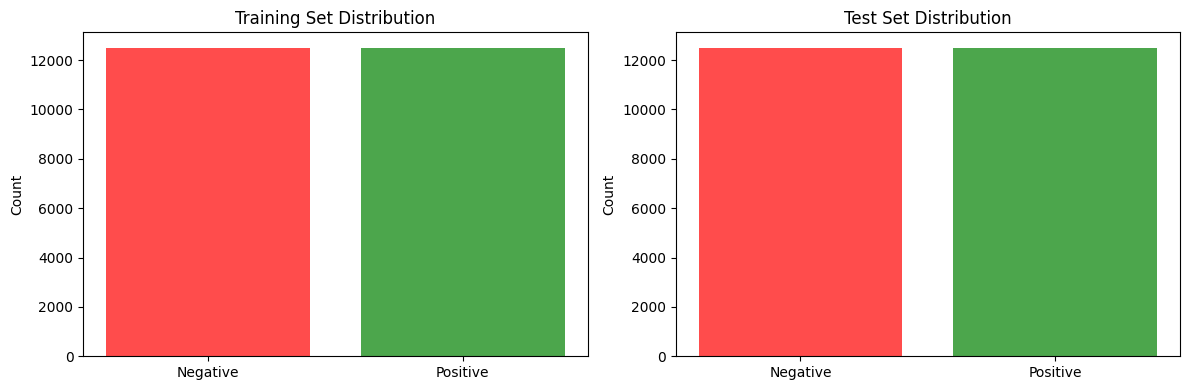

In [7]:
# Plot class distribution inline using the loaded dataset
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_labels = train_data['label']
train_counts = [train_labels.count(0), train_labels.count(1)]
axes[0].bar(['Negative', 'Positive'], train_counts, color=['red', 'green'], alpha=0.7)
axes[0].set_title('Training Set Distribution')
axes[0].set_ylabel('Count')

test_labels = test_data['label']
test_counts = [test_labels.count(0), test_labels.count(1)]
axes[1].bar(['Negative', 'Positive'], test_counts, color=['red', 'green'], alpha=0.7)
axes[1].set_title('Test Set Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

C:\Users\franc\AppData\Local\Temp\ipykernel_5688\692325909.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


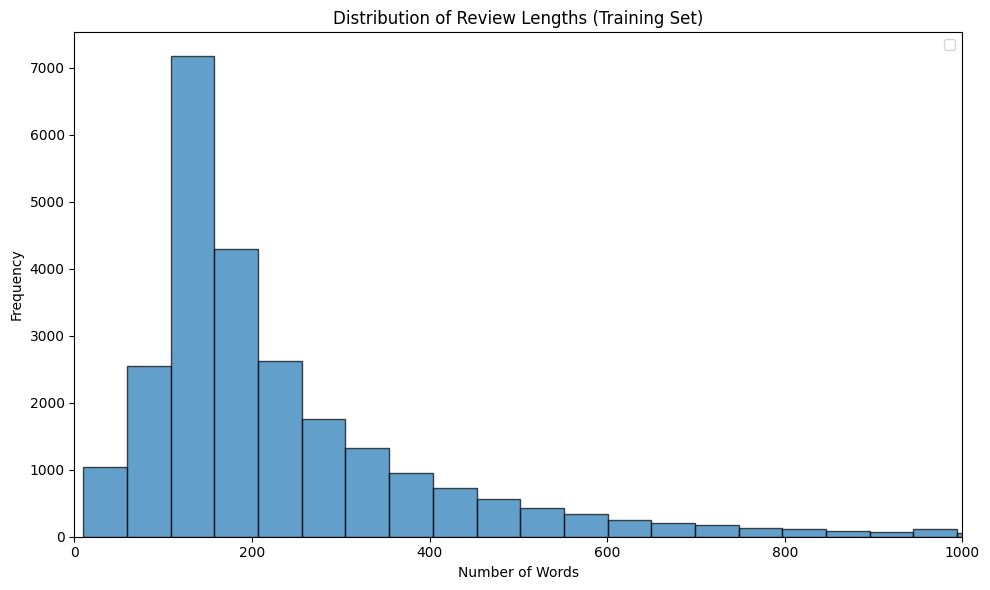

In [8]:
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Review Lengths (Training Set)')
plt.legend()
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()

## 2) Tokenization & DataLoaders

In [9]:
# Tokenizer and DataLoaders
# Build tokenizer and create DataLoaders for train/val/test splits.
# PyTorch DataLoaders ready for the training loop.

tokenizer = BERTTokenizer()
train_texts, val_texts, train_labels, val_labels = train_test_split(
    list(train_data['text']),
    list(train_data['label']),
    test_size=0.1,
    random_state=42,
    stratify=list(train_data['label'])
)
test_texts = test_data['text']
test_labels = test_data['label']

# from tokenizer.py file
train_loader, val_loader, test_loader = create_dataloaders(
    train_texts, train_labels, val_texts, val_labels,
    test_texts, test_labels, tokenizer, batch_size=BATCH_SIZE, max_length=MAX_LENGTH
)

Vocabulary size: 30522
DataLoaders created:
  Training samples: 22500 (1407 batches)
  Validation samples: 2500 (157 batches)
  Test samples: 25000 (1563 batches)
  Batch size: 16
  Max sequence length: 256


## 3) Models & Training

This section trains five models for comparison:
- `BERT Fine-tuned`: full fine-tuning of `bert-base-uncased`.
- `BERT Partial`: mostly frozen BERT with only the last transformer layers fine-tuned.
- `BERT Frozen`: BERT used as a frozen feature extractor with a small head.
- `LSTM` and `MLP` baselines: quick, lightweight neural baselines trained from scratch.
- `TF-IDF + Logistic Regression`: a classical bag-of-words baseline.

In [10]:
'''
# Grid Search

# Define hyperparameter grid
learning_rates = [1e-5, 2e-5, 3e-5]
epochs_options = [2, 3, 4]
batch_sizes = [16]

# Store results
grid_results = []

for lr in learning_rates:
    for epochs in epochs_options:
        for batch_size in batch_sizes:
            print(f"Training: LR={lr}, EPOCHS={epochs}, BATCH_SIZE={batch_size}")

            # Recreate dataloaders with new batch size
            train_loader_gs, val_loader_gs, test_loader_gs = create_dataloaders(
                train_texts, train_labels, val_texts, val_labels,
                test_texts, test_labels, tokenizer, batch_size=batch_size, max_length=MAX_LENGTH
            )

            # Create and train model
            model_gs = BERTSentimentClassifier(freeze_bert=False)
            trainer_gs = Trainer(
                model_gs,
                train_loader_gs,
                val_loader_gs,
                test_loader_gs,
                device,
                lr,
                RESULTS_DIR,
                save_artifacts=False
            )

            # Train
            trainer_gs.train(epochs)

            # Evaluate on validation and test sets
            val_loss, val_accuracy, val_f1, _, _ = trainer_gs.evaluate(val_loader_gs)
            test_metrics = trainer_gs.evaluate_test(plot_confusion_matrix=False)

            # Store results
            grid_results.append({
                'learning_rate': lr,
                'epochs': epochs,
                'batch_size': batch_size,
                'val_accuracy': val_accuracy,
                'val_f1': val_f1,
                'test_accuracy': test_metrics['accuracy'],
                'test_f1': test_metrics['f1']
            })

            print(f"Val F1: {val_f1:.4f} | Test F1: {test_metrics['f1']:.4f}\n")

# Convert to DataFrame
grid_results_df = pd.DataFrame(grid_results)

# Show results directly in the notebook
print("Grid Search Results (sorted by validation F1)")
print(grid_results_df.sort_values('val_f1', ascending=False).to_string(index=False))

# Find best configuration
best_idx = grid_results_df['val_f1'].idxmax()
best_config = grid_results_df.loc[best_idx]

print("Best results")
print(f"Learning Rate: {best_config['learning_rate']}")
print(f"Epochs: {best_config['epochs']}")
print(f"Batch Size: {best_config['batch_size']}")
print(f"Validation F1: {best_config['val_f1']:.4f}")
print(f"Test F1: {best_config['test_f1']:.4f}")

'''

'\n# Grid Search\n\n# Define hyperparameter grid\nlearning_rates = [1e-5, 2e-5, 3e-5]\nepochs_options = [2, 3, 4]\nbatch_sizes = [16]\n\n# Store results\ngrid_results = []\n\nfor lr in learning_rates:\n    for epochs in epochs_options:\n        for batch_size in batch_sizes:\n            print(f"Training: LR={lr}, EPOCHS={epochs}, BATCH_SIZE={batch_size}")\n\n            # Recreate dataloaders with new batch size\n            train_loader_gs, val_loader_gs, test_loader_gs = create_dataloaders(\n                train_texts, train_labels, val_texts, val_labels,\n                test_texts, test_labels, tokenizer, batch_size=batch_size, max_length=MAX_LENGTH\n            )\n\n            # Create and train model\n            model_gs = BERTSentimentClassifier(freeze_bert=False)\n            trainer_gs = Trainer(\n                model_gs,\n                train_loader_gs,\n                val_loader_gs,\n                test_loader_gs,\n                device,\n                lr,\n      

In [11]:
#best option
EPOCHS_BERT = 4
LEARNING_RATE_BERT = 3e-5

BERT FINE TUNED

In [ ]:
# BERT fine-tuned
# from model.py and trainer.py files
print('Training BERT (fine-tuned)')
model_bert = BERTSentimentClassifier(freeze_bert=False)
trainer_bert = Trainer(model_bert, train_loader, val_loader, test_loader, device, LEARNING_RATE_BERT, f'{RESULTS_DIR}/bert_finetuned')
trainer_bert.train(EPOCHS_BERT, save_best=True, best_metric='val_f1')
trainer_bert.load_checkpoint()
bert_results = trainer_bert.evaluate_test()

Training BERT (fine-tuned)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Epoch 1/4


Training:   0%|          | 0/1407 [00:00<?, ?it/s]

BERT FROZEN

In [ ]:
# BERT frozen
print('Training BERT (frozen)')
model_frozen = BERTSentimentClassifier(freeze_bert=True)
trainer_frozen = Trainer(model_frozen, train_loader, val_loader, test_loader, device, LEARNING_RATE_BASELINE, f'{RESULTS_DIR}/bert_frozen')
trainer_frozen.train(EPOCHS_BASELINE, save_best=True, best_metric='val_f1')
trainer_frozen.load_checkpoint()
frozen_results = trainer_frozen.evaluate_test()

Training BERT (frozen)

Epoch 1/5


Training: 100%|██████████| 1407/1407 [03:40<00:00,  6.39it/s]


Train Loss: 0.5658, Acc: 0.7047
Val Loss: 0.4774, Acc: 0.7844, F1: 0.8792

Epoch 2/5


Training: 100%|██████████| 1407/1407 [03:39<00:00,  6.42it/s]


Train Loss: 0.5094, Acc: 0.7499
Val Loss: 0.4824, Acc: 0.7684, F1: 0.8690

Epoch 3/5


...

Train Loss: 0.4998, Acc: 0.7588
Val Loss: 0.3402, Acc: 0.8632, F1: 0.9266

Epoch 4/5


Training: 100%|██████████| 1407/1407 [03:44<00:00,  6.27it/s]


Train Loss: 0.4976, Acc: 0.7624
Val Loss: 0.6549, Acc: 0.6472, F1: 0.7858

Epoch 5/5


Training: 100%|██████████| 1407/1407 [03:47<00:00,  6.19it/s]


Train Loss: 0.4913, Acc: 0.7615
Val Loss: 0.5003, Acc: 0.7580, F1: 0.8623

Test Accuracy: 0.8042
Test F1 Score: 0.8036

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.86      0.81     12500
    Positive       0.84      0.75      0.79     12500

    accuracy                           0.80     25000
   macro avg       0.81      0.80      0.80     25000
weighted avg       0.81      0.80      0.80     25000



BERT PART FROZEN

In [ ]:
# BERT partially fine-tuned
print(f'Training BERT (last {PARTIAL_UNFREEZE_LAYERS} layers fine-tuned)')
model_partial = BERTSentimentClassifier(freeze_bert=True)
model_partial.unfreeze_layers(PARTIAL_UNFREEZE_LAYERS)

trainable_params = sum(p.numel() for p in model_partial.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_partial.parameters())
print(f'Trainable parameters: {trainable_params:,} / {total_params:,}')

trainer_partial = Trainer(model_partial, train_loader, val_loader, test_loader, device, LEARNING_RATE_BERT, f'{RESULTS_DIR}/bert_partial')
trainer_partial.train(EPOCHS_BERT, save_best=True, best_metric='val_f1')
trainer_partial.load_checkpoint()
partial_results = trainer_partial.evaluate_test()

LSTM BASELINE

In [ ]:
# LSTM baseline
print('Training LSTM baseline')
model_lstm = BaselineLSTM(vocab_size=tokenizer.vocab_size)
trainer_lstm = Trainer(model_lstm, train_loader, val_loader, test_loader, device, LEARNING_RATE_BASELINE, f'{RESULTS_DIR}/lstm')
trainer_lstm.train(EPOCHS_BASELINE, save_best=True, best_metric='val_f1')
trainer_lstm.load_checkpoint()
lstm_results = trainer_lstm.evaluate_test()

Training LSTM baseline

Epoch 1/5


Training: 100%|██████████| 1407/1407 [02:20<00:00, 10.02it/s]


Train Loss: 0.6190, Acc: 0.6409
Val Loss: 0.4216, Acc: 0.8384, F1: 0.9121

Epoch 2/5


Training: 100%|██████████| 1407/1407 [02:18<00:00, 10.17it/s]


Train Loss: 0.3488, Acc: 0.8592
Val Loss: 0.3562, Acc: 0.8904, F1: 0.9420

Epoch 3/5


...

Train Loss: 0.2186, Acc: 0.9210
Val Loss: 0.6196, Acc: 0.7784, F1: 0.8754

Epoch 4/5


Training: 100%|██████████| 1407/1407 [02:18<00:00, 10.15it/s]


Train Loss: 0.1268, Acc: 0.9592
Val Loss: 0.6885, Acc: 0.7920, F1: 0.8839

Epoch 5/5


Training: 100%|██████████| 1407/1407 [02:16<00:00, 10.32it/s]


Train Loss: 0.0703, Acc: 0.9788
Val Loss: 0.9183, Acc: 0.7760, F1: 0.8739

Test Accuracy: 0.8323
Test F1 Score: 0.8322

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.86      0.84     12500
    Positive       0.85      0.81      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



MLP BASELINE

In [ ]:
# MLP baseline
print('Training MLP baseline')
model_mlp = BaselineMLP(vocab_size=tokenizer.vocab_size)
trainer_mlp = Trainer(model_mlp, train_loader, val_loader, test_loader, device, LEARNING_RATE_BASELINE, f'{RESULTS_DIR}/mlp')
trainer_mlp.train(EPOCHS_BASELINE, save_best=True, best_metric='val_f1')
trainer_mlp.load_checkpoint()
mlp_results = trainer_mlp.evaluate_test()

Training MLP baseline

Epoch 1/5


Training: 100%|██████████| 1407/1407 [01:09<00:00, 20.29it/s]


Train Loss: 0.4202, Acc: 0.8019
Val Loss: 0.4534, Acc: 0.7876, F1: 0.8812

Epoch 2/5


Training: 100%|██████████| 1407/1407 [01:11<00:00, 19.67it/s]


Train Loss: 0.2413, Acc: 0.9054
Val Loss: 0.6270, Acc: 0.7256, F1: 0.8410

Epoch 3/5


...

Train Loss: 0.1684, Acc: 0.9383
Val Loss: 0.7860, Acc: 0.7004, F1: 0.8238

Epoch 4/5


Training: 100%|██████████| 1407/1407 [01:13<00:00, 19.14it/s]


Train Loss: 0.1151, Acc: 0.9604
Val Loss: 0.6658, Acc: 0.7664, F1: 0.8678

Epoch 5/5


Training: 100%|██████████| 1407/1407 [01:14<00:00, 18.86it/s]


Train Loss: 0.0778, Acc: 0.9732
Val Loss: 0.8472, Acc: 0.7616, F1: 0.8647

Test Accuracy: 0.8220
Test F1 Score: 0.8219

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.85      0.83     12500
    Positive       0.84      0.79      0.82     12500

    accuracy                           0.82     25000
   macro avg       0.82      0.82      0.82     25000
weighted avg       0.82      0.82      0.82     25000



TF IDF BASELINE

In [ ]:
# Classical baseline: TF-IDF + Logistic Regression
# This is a strong non-neural baseline for sentiment analysis and gives a useful
# comparison against models trained from scratch and BERT-based models.
print('Training TF-IDF + Logistic Regression baseline')

tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(train_texts)
X_test_tfidf = tfidf.transform(test_texts)

logreg = LogisticRegression(max_iter=1000, n_jobs=-1)
logreg.fit(X_train_tfidf, train_labels)

tfidf_preds = logreg.predict(X_test_tfidf)
tfidf_results = {
    'accuracy': accuracy_score(test_labels, tfidf_preds),
    'f1': f1_score(test_labels, tfidf_preds, average='weighted'),
    'predictions': tfidf_preds,
    'labels': test_labels
}

print(f"Test Accuracy: {tfidf_results['accuracy']:.4f}")
print(f"Test F1 Score: {tfidf_results['f1']:.4f}")
print(classification_report(test_labels, tfidf_preds, target_names=['Negative', 'Positive']))

## 4) Compare results and save outputs

          Model  Accuracy       F1
BERT Fine-tuned   0.91436 0.914359
    BERT Frozen   0.80416 0.803575
           LSTM   0.83228 0.832170
            MLP   0.82204 0.821893


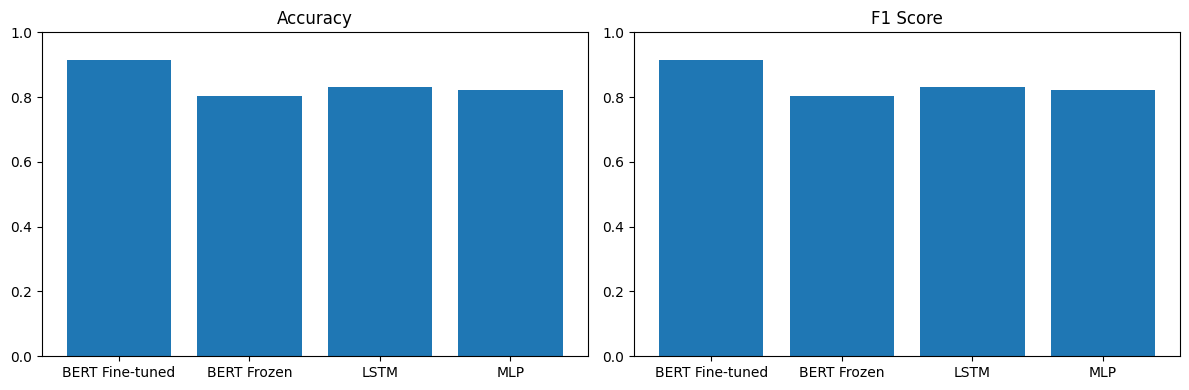

In [ ]:
# Collate and save results
results_df = pd.DataFrame({
    'Model': ['BERT Fine-tuned', 'BERT Partial', 'BERT Frozen', 'LSTM', 'MLP', 'TF-IDF + LogReg'],
    'Accuracy': [bert_results['accuracy'], partial_results['accuracy'], frozen_results['accuracy'], lstm_results['accuracy'], mlp_results['accuracy'], tfidf_results['accuracy']],
    'F1': [bert_results['f1'], partial_results['f1'], frozen_results['f1'], lstm_results['f1'], mlp_results['f1'], tfidf_results['f1']]
})
print(results_df.to_string(index=False))
results_df.to_csv(f'{RESULTS_DIR}/final_comparison.csv', index=False)

# Show the comparison directly in the notebook
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(results_df['Model'], results_df['Accuracy'])
ax[0].set_title('Accuracy')
ax[0].set_ylim([0, 1])
ax[1].bar(results_df['Model'], results_df['F1'])
ax[1].set_title('F1 Score')
ax[1].set_ylim([0, 1])
plt.tight_layout()
plt.show()

## 5) Comparative Analysis

The baselines answer different parts of the project question:

- `TF-IDF + Logistic Regression` is a classical bag-of-words baseline. It does not use neural representations or word order, but it is often strong for sentiment because sentiment words and short phrases are very predictive.
- `MLP` and `LSTM` are neural baselines trained from scratch. They use trainable embeddings but do not start from pretrained language knowledge.
- `BERT Frozen` tests whether pretrained BERT representations are useful without adapting the encoder to IMDb.
- `BERT Partial` tests a middle strategy: adapt only the last transformer layers while keeping most pretrained knowledge fixed.
- `BERT Fine-tuned` tests full task adaptation, where all BERT layers and the classifier head are trained on IMDb.

This lets us compare both baseline model families and fine-tuning strategies. If full BERT beats frozen BERT, the gain comes from task-specific adaptation rather than only from using pretrained representations. If partial BERT is close to full BERT, it suggests that adapting the upper layers is enough for much of the sentiment signal.

For data selection, we use a stratified train/validation split so the validation set keeps the positive/negative balance of IMDb. This makes model selection more reliable than slicing the dataset by order. For data augmentation, we did not add synthetic examples in the main experiment because naive text augmentation can change sentiment labels. Reasonable future options would be back-translation, synonym replacement with manual checks, or targeted augmentation of short/ambiguous reviews.

- Consider adding qualitative error analysis and experiments with other pre-trained models (RoBERTa, DistilBERT).

In [ ]:
# Short numeric summary for the report/presentation
comparison = results_df.sort_values('F1', ascending=False).reset_index(drop=True)
print(comparison.to_string(index=False))

scratch_models = ['MLP', 'LSTM']
best_scratch = results_df[results_df['Model'].isin(scratch_models)].sort_values('F1', ascending=False).iloc[0]
bert_ft_f1 = results_df.loc[results_df['Model'] == 'BERT Fine-tuned', 'F1'].iloc[0]
frozen_f1 = results_df.loc[results_df['Model'] == 'BERT Frozen', 'F1'].iloc[0]

print(f"\nFine-tuned BERT vs best scratch baseline ({best_scratch['Model']}): {bert_ft_f1 - best_scratch['F1']:+.4f} F1")
print(f"Fine-tuned BERT vs frozen BERT: {bert_ft_f1 - frozen_f1:+.4f} F1")

## 6) Qualitative Error and OOD Analysis

The final metric table tells us how often each model is correct, but not why errors happen. Here we inspect examples misclassified by the fine-tuned BERT model and look for out-of-distribution or difficult cases: very long reviews, mixed sentiment, sarcasm/irony, noisy HTML formatting, plot-heavy reviews, and ambiguous labels.

For this project, OOD does not mean a completely different dataset. It means examples that are unlike simple sentiment statements and therefore stress the assumptions of the model and dataset.

In [ ]:
# Build a table of fine-tuned BERT mistakes
label_names = {0: 'Negative', 1: 'Positive'}
error_rows = []

for i, (pred, label) in enumerate(zip(bert_results['predictions'], bert_results['labels'])):
    if int(pred) == int(label):
        continue

    text = str(test_texts[i])
    words = text.split()
    error_rows.append({
        'index': i,
        'true_label': label_names[int(label)],
        'predicted_label': label_names[int(pred)],
        'num_words': len(words),
        'has_html': '<br' in text.lower(),
        'has_negation': any(w.lower().strip(".,!?;:'\"") in {'not', "n't", 'never', 'no'} for w in words),
        'preview': text[:700].replace('\n', ' ')
    })

errors_df = pd.DataFrame(error_rows)
print(f"Misclassified examples: {len(errors_df)} / {len(test_texts)}")
display(errors_df.head(10))

In [ ]:
# Surface likely difficult/OOD-style cases for manual inspection
long_errors = errors_df.sort_values('num_words', ascending=False).head(5)
html_errors = errors_df[errors_df['has_html']].head(5)
negation_errors = errors_df[errors_df['has_negation']].head(5)

print('Longest misclassified reviews:')
display(long_errors[['index', 'true_label', 'predicted_label', 'num_words', 'preview']])

print('Misclassified reviews with HTML/noisy formatting:')
display(html_errors[['index', 'true_label', 'predicted_label', 'num_words', 'preview']])

print('Misclassified reviews with negation cues:')
display(negation_errors[['index', 'true_label', 'predicted_label', 'num_words', 'preview']])

In [ ]:
# Save examples for the report/slides
error_sample = pd.concat([
    long_errors.assign(category='long_review_or_truncation'),
    html_errors.assign(category='html_or_formatting_noise'),
    negation_errors.assign(category='negation_or_complex_sentiment')
]).drop_duplicates(subset='index')

error_path = f'{RESULTS_DIR}/bert_finetuned/error_analysis_examples.csv'
error_sample.to_csv(error_path, index=False)
print(f'Saved qualitative error examples to {error_path}')

### Qualitative Findings to Report

After running the cells above, inspect 3-5 examples and summarize them in the report/presentation. Useful categories are:

- **Long-review truncation:** IMDb reviews can be much longer than 256 tokens, so BERT may miss decisive sentiment late in the review.
- **Mixed sentiment:** Some reviews praise acting, visuals, or music while criticizing story or pacing. Binary labels hide this nuance.
- **Sarcasm and irony:** Positive words can express negative sentiment depending on tone.
- **Formatting/noise:** IMDb contains HTML breaks and informal writing, which can distract the model.
- **Ambiguous labels:** Some reviews are closer to neutral or mixed, but IMDb forces a positive/negative label.

These cases reveal weaknesses of both the dataset and the pretrained model. The dataset simplifies nuanced opinions into binary labels, while BERT can still struggle with sarcasm, long-range evidence, and sentiment cues outside the first 256 tokens.